# EDGE AI Project — Indian Traffic Analyzer (Training & Compression)

1. **Phase 1 — Data Collection**: Downloads UVH-26 from HuggingFace, converts COCO→YOLO format
2. **Phase 2 — Model Development**: Fine-tunes YOLO11n (or YOLOv8n) on the 14 Indian classes
3. **Phase 3 — Model Compression**: Exports FP32 ONNX, FP16 NCNN, and INT8 NCNN with calibration; benchmarks all three




---
##Setup



In [1]:
# Check GPU
import subprocess
try:
    out = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader']
    ).decode()
    print("GPU:", out.strip())
except Exception:
    print("WARNING: No GPU detected.")

GPU: NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
from huggingface_hub import login

HF_TOKEN = "####"
login(token=HF_TOKEN, add_to_git_credential=False)

In [3]:
# Install dependencies
%pip install -q ultralytics huggingface_hub pycocotools opencv-python-headless pyyaml pandas matplotlib lap supervision onnx onnxsim tqdm
%pip install -q ncnn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 135.9 MB/s eta 0:00:00


In [4]:
import os, sys, time, json, shutil, random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import yaml
import torch
from tqdm import tqdm
from ultralytics import YOLO

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
PROJECT_ROOT = Path('/content/edge_traffic') if Path('/content').exists() else Path.cwd() / 'edge_traffic'
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("Project root:", PROJECT_ROOT)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cu128 | CUDA: True
Project root: /content/edge_traffic


---
## Phase 1 — Data Collection (UVH-26, subset-first download)


The full dataset is **~90 GB of PNGs** — way more than we need
1. **Download only the annotation JSONs** first (a few hundred MB). These contain every image's filename and the COCO bounding boxes.
2. **Pick a random subset** of images from the annotations using `SUBSET_FRACTION`.
3. **Download only the chosen image files** via `hf_hub_download` (per-file fetch, no full snapshot).
4. Convert just those to YOLO format.



In [5]:

# 1.1  Download ONLY the annotation JSONs from HuggingFace


from huggingface_hub import hf_hub_download

REPO_ID = 'iisc-aim/UVH-26'
ANNOTATION_VARIANT = 'MV'

HF_CACHE = PROJECT_ROOT / 'hf_cache'
HF_CACHE.mkdir(exist_ok=True)

print("Downloading annotation JSONs only (~few hundred MB)...")
train_json = Path(hf_hub_download(
    repo_id=REPO_ID, repo_type='dataset',
    filename=f'UVH-26-Train/UVH-26-{ANNOTATION_VARIANT}-Train.json',
    cache_dir=str(HF_CACHE),
))
val_json = Path(hf_hub_download(
    repo_id=REPO_ID, repo_type='dataset',
    filename=f'UVH-26-Val/UVH-26-{ANNOTATION_VARIANT}-Val.json',
    cache_dir=str(HF_CACHE),
))
print("Train JSON:", train_json, f"({train_json.stat().st_size/1e6:.1f} MB)")
print("Val   JSON:", val_json,   f"({val_json.stat().st_size/1e6:.1f} MB)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


UVH-26-Train/UVH-26-MV-Train.json:   0%|          | 0.00/63.6M [00:00<?, ?B/s]

UVH-26-Val/UVH-26-MV-Val.json:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

Train JSON: /content/edge_traffic/hf_cache/datasets--iisc-aim--UVH-26/snapshots/59f82c57821e8a54dc40bc1f42e83909dbad0b70/UVH-26-Train/UVH-26-MV-Train.json (63.6 MB)
Val   JSON: /content/edge_traffic/hf_cache/datasets--iisc-aim--UVH-26/snapshots/59f82c57821e8a54dc40bc1f42e83909dbad0b70/UVH-26-Val/UVH-26-MV-Val.json (16.0 MB)


In [6]:
# ============================================================
# 1.2 - Inspect the COCO annotations
# ============================================================
print("Loading COCO JSONs (each is a few hundred MB; takes ~30s)...")
with open(train_json) as f: coco_train = json.load(f)
with open(val_json)   as f: coco_val   = json.load(f)

print()
print("Train images:     ", len(coco_train['images']))
print("Train annotations:", len(coco_train['annotations']))
print("Val images:       ", len(coco_val['images']))
print("Val annotations:  ", len(coco_val['annotations']))
print()
print("Categories (UVH-26 14-class taxonomy):")
for c in sorted(coco_train['categories'], key=lambda x: x['id']):
    print(f"  {c['id']:>2}: {c['name']}")

Loading COCO JSONs (each is a few hundred MB; takes ~30s)...

Train images:      21349
Train annotations: 252723
Val images:        5297
Val annotations:   63497

Categories (UVH-26 14-class taxonomy):
   1: Hatchback
   2: Sedan
   3: SUV
   4: MUV
   5: Bus
   6: Truck
   7: Three-wheeler
   8: Two-wheeler
   9: LCV
  10: Mini-bus
  11: Tempo-traveller
  12: Bicycle
  13: Van
  14: Others


In [7]:
# ============================================================
# 1.3 - Build COCO category id -> 0-indexed YOLO class id mapping
# ============================================================


cats = sorted(coco_train['categories'], key=lambda x: x['id'])
COCO_ID_TO_YOLO = {c['id']: i for i, c in enumerate(cats)}
CLASS_NAMES = [c['name'] for c in cats]

print("YOLO class index -> name:")
for i, n in enumerate(CLASS_NAMES):
    print(f"  {i}: {n}")
print()
print("Total classes:", len(CLASS_NAMES))

YOLO class index -> name:
  0: Hatchback
  1: Sedan
  2: SUV
  3: MUV
  4: Bus
  5: Truck
  6: Three-wheeler
  7: Two-wheeler
  8: LCV
  9: Mini-bus
  10: Tempo-traveller
  11: Bicycle
  12: Van
  13: Others

Total classes: 14


In [8]:

# 1.4 - Pick the subset

SUBSET_FRACTION = 0.5

random.seed(SEED)
n_val_cap = min(1500, len(coco_val['images']))
val_take = min(int(len(coco_val['images']) * SUBSET_FRACTION * 0.5), n_val_cap)
n_train_keep = int(len(coco_train['images']) * SUBSET_FRACTION)

train_subset = random.sample(coco_train['images'], n_train_keep)
val_subset   = random.sample(coco_val['images'],   val_take)

print(f"Train subset: {n_train_keep} / {len(coco_train['images'])} images")
print(f"Val   subset: {val_take} / {len(coco_val['images'])} images")
print(f"Sample train file_name: {train_subset[0]['file_name']}")
print(f"Sample val   file_name: {val_subset[0]['file_name']}")


Train subset: 10674 / 21349 images
Val   subset: 1324 / 5297 images
Sample train file_name: 271669.png
Sample val   file_name: 557146.png


In [9]:
# ============================================================
# 1.5 - Resolve actual repo paths via list_repo_files

from huggingface_hub import HfApi, hf_hub_download
api = HfApi()

print("Listing UVH-26 file tree (one network call)...")
all_files = api.list_repo_files(REPO_ID, repo_type='dataset')
image_files = [p for p in all_files if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"  Total files in repo: {len(all_files)}")
print(f"  Image files in repo: {len(image_files)}")
print()

print("Sample image paths from the repo (first 5):")
for p in image_files[:5]:
    print(f"  {p}")
print()

print("Sample COCO file_name values:")
print(f"  train[0].file_name = {train_subset[0]['file_name']!r}")
print(f"  val[0].file_name   = {val_subset[0]['file_name']!r}")
print()

]
basename_idx = {}
suffix_idx   = {}
for p in image_files:
    basename_idx[Path(p).name] = p

    parts = p.split('/')
    for k in range(1, len(parts)):
        suffix_idx['/'.join(parts[k:])] = p

print(f"basename_idx size: {len(basename_idx)}")
print(f"suffix_idx   size: {len(suffix_idx)}")
print()


def resolve_one(file_name):


    if file_name in basename_idx:
        return basename_idx[file_name]

    bn = Path(file_name).name
    if bn in basename_idx:
        return basename_idx[bn]

    norm = file_name.replace('\\', '/').lstrip('/')
    if norm in suffix_idx:
        return suffix_idx[norm]

    if bn in suffix_idx:
        return suffix_idx[bn]
    return None



train_hits = sum(1 for img in train_subset[:100] if resolve_one(img['file_name']))
val_hits   = sum(1 for img in val_subset[:100]   if resolve_one(img['file_name']))
print(f"Resolution probe (first 100 of each):")
print(f"  Train: {train_hits}/100 resolved")
print(f"  Val:   {val_hits}/100 resolved")

if train_hits == 0 or val_hits == 0:
    print()
    print("=" * 60)
    print("RESOLUTION FAILED. Diagnostics:")
    print("=" * 60)
    print(f"  Total image_files seen in repo: {len(image_files)}")
    print(f"  Sample repo paths: {image_files[:5]}")
    print(f"  Sample basenames in basename_idx: {list(basename_idx.keys())[:5]}")
    print(f"  Train file_name samples: {[img['file_name'] for img in train_subset[:5]]}")
    print(f"  Val   file_name samples: {[img['file_name'] for img in val_subset[:5]]}")
    raise RuntimeError(
        "Repo paths and COCO file_name fields don't match by any known key. "
        "Inspect the samples above."
    )

print()
print(f"OK: resolver works for both splits.")


Listing UVH-26 file tree (one network call)...
  Total files in repo: 26653
  Image files in repo: 26646

Sample image paths from the repo (first 5):
  UVH-26-Train/data/000/100103.png
  UVH-26-Train/data/000/100156.png
  UVH-26-Train/data/000/10020.png
  UVH-26-Train/data/000/100201.png
  UVH-26-Train/data/000/100283.png

Sample COCO file_name values:
  train[0].file_name = '271669.png'
  val[0].file_name   = '557146.png'

basename_idx size: 26646
suffix_idx   size: 79938

Resolution probe (first 100 of each):
  Train: 100/100 resolved
  Val:   100/100 resolved

OK: resolver works for both splits.


In [ ]:
# 1.6 - Parallel bulk download of the chosen images

from concurrent.futures import ThreadPoolExecutor, as_completed
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
def fetch_one(file_name):
    rp = resolve_one(file_name)
    if rp is None:
        return file_name, None, "not in index"
    try:
        local = hf_hub_download(
            repo_id=REPO_ID, repo_type='dataset',
            filename=rp,
            cache_dir=str(HF_CACHE),
        )
        return file_name, Path(local), None
    except Exception as e:
        return file_name, None, str(e)[:200]


def bulk_download(image_records, label, max_workers=8):
    print(f"[{label}] downloading {len(image_records)} files...")
    local_map = {}
    errors = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = [ex.submit(fetch_one, img['file_name']) for img in image_records]
        done = 0
        for fut in as_completed(futs):
            fn, local, err = fut.result()
            done += 1
            if err:
                errors.append((fn, err))
            else:
                local_map[fn] = local
            if done % 200 == 0 or done == len(futs):
                print(f"  [{label}] {done}/{len(futs)}  errors={len(errors)}")
    if errors:
        print(f"  [{label}] {len(errors)} errors. First 3:")
        for fn, e in errors[:3]:
            print(f"    {fn}: {e[:150]}")
    return local_map


print("Downloading TRAIN images...")
train_local = bulk_download(train_subset, 'train')

print()
print("Downloading VAL images...")
val_local = bulk_download(val_subset, 'val')

print()
print(f"train_local: {len(train_local)} / {len(train_subset)} files")
print(f"val_local:   {len(val_local)} / {len(val_subset)} files")
assert len(train_local) > 0, "Train download produced 0 files."
assert len(val_local)   > 0, "Val download produced 0 files."


In [11]:
# ============================================================
# 1.7 - Convert COCO -> YOLO TXT format (subset only)
# ============================================================
YOLO_ROOT = PROJECT_ROOT / 'uvh26_yolo'
for s in ('images/train', 'images/val', 'labels/train', 'labels/val'):
    (YOLO_ROOT / s).mkdir(parents=True, exist_ok=True)


print("Grouping annotations by image_id...")
train_anns_by_img = {}
for a in coco_train['annotations']:
    train_anns_by_img.setdefault(a['image_id'], []).append(a)
val_anns_by_img = {}
for a in coco_val['annotations']:
    val_anns_by_img.setdefault(a['image_id'], []).append(a)


def coco_to_yolo(image_records, local_map, split_name, anns_by_img):
    kept, missing = 0, 0
    for img in tqdm(image_records, desc=f"convert {split_name}"):
        src = local_map.get(img['file_name'])
        if src is None:
            missing += 1
            continue

        W, H = img['width'], img['height']
        anns = anns_by_img.get(img['id'], [])
        lines = []
        for a in anns:
            cid = COCO_ID_TO_YOLO.get(a['category_id'])
            if cid is None:
                continue
            x, y, w, h = a['bbox']
            if w <= 1 or h <= 1: continue
            xc = (x + w / 2) / W
            yc = (y + h / 2) / H
            wn = w / W
            hn = h / H
            xc = max(0.0, min(1.0, xc))
            yc = max(0.0, min(1.0, yc))
            wn = max(0.0, min(1.0, wn))
            hn = max(0.0, min(1.0, hn))
            lines.append(f"{cid} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

        # Symlink the HF-cached image into the YOLO tree (saves disk vs copy).
        dst_img = YOLO_ROOT / 'images' / split_name / src.name
        if not dst_img.exists():
            try:
                os.symlink(src.resolve(), dst_img)
            except OSError:
                shutil.copy2(src, dst_img)

        dst_lbl = YOLO_ROOT / 'labels' / split_name / (Path(src.name).stem + '.txt')
        dst_lbl.write_text("\n".join(lines))
        kept += 1

    print(f"  [{split_name}] kept={kept}  missing-from-download={missing}")


coco_to_yolo(train_subset, train_local, 'train', train_anns_by_img)
coco_to_yolo(val_subset,   val_local,   'val',   val_anns_by_img)


Grouping annotations by image_id...


convert train: 100%|██████████| 10674/10674 [00:03<00:00, 3271.78it/s]


  [train] kept=10674  missing-from-download=0


convert val: 100%|██████████| 1324/1324 [00:00<00:00, 2984.65it/s]

  [val] kept=1324  missing-from-download=0


In [12]:
# ============================================================
# 1.8 - Write data.yaml for Ultralytics
# ============================================================
DATA_YAML = YOLO_ROOT / 'data.yaml'
yaml_dict = {
    'path': str(YOLO_ROOT.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'names': {i: n for i, n in enumerate(CLASS_NAMES)},
}
DATA_YAML.write_text(yaml.safe_dump(yaml_dict, sort_keys=False))
print("Wrote", DATA_YAML)
print()
print(DATA_YAML.read_text())


Wrote /content/edge_traffic/uvh26_yolo/data.yaml

path: /content/edge_traffic/uvh26_yolo
train: images/train
val: images/val
names:
  0: Hatchback
  1: Sedan
  2: SUV
  3: MUV
  4: Bus
  5: Truck
  6: Three-wheeler
  7: Two-wheeler
  8: LCV
  9: Mini-bus
  10: Tempo-traveller
  11: Bicycle
  12: Van
  13: Others



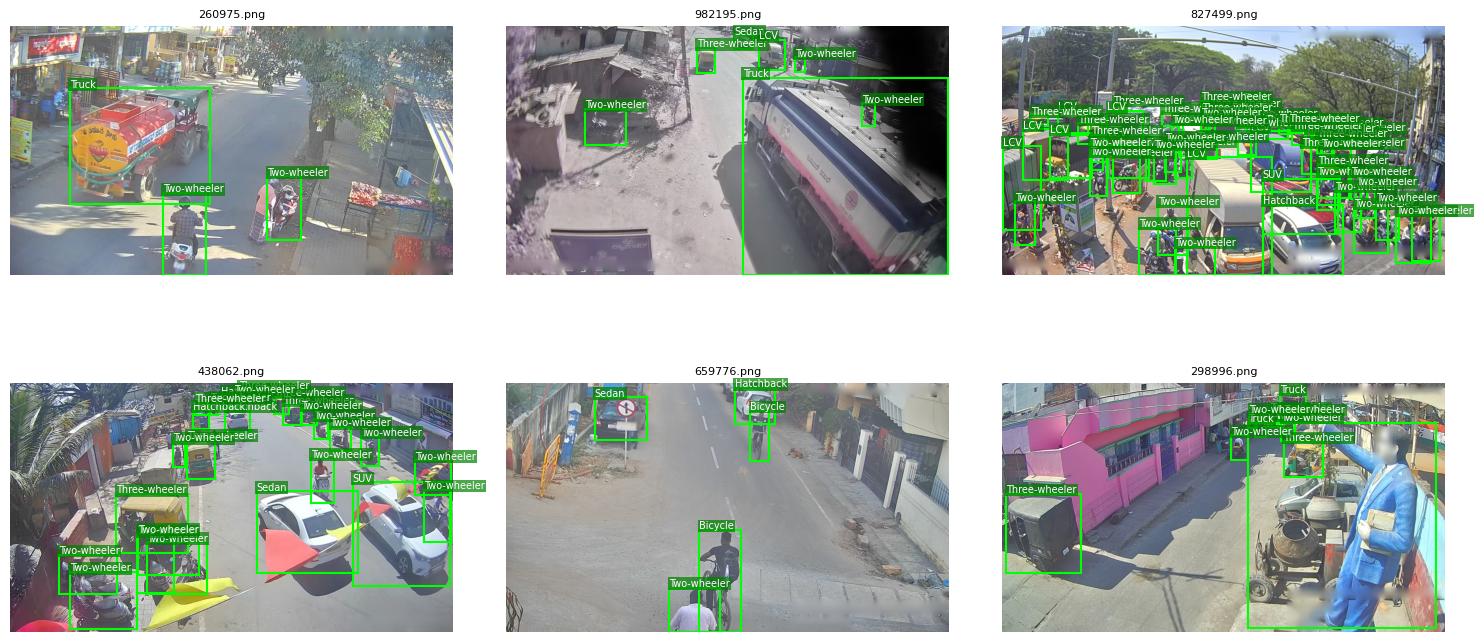

In [13]:

# 1.9 - Sanity check: visualize a few labelled training images

import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_imgs = list((YOLO_ROOT / 'images' / 'train').iterdir())[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, ip in zip(axes.flatten(), sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    lp = YOLO_ROOT / 'labels' / 'train' / (ip.stem + '.txt')
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            parts = line.split()
            cid = int(parts[0]); xc, yc, w, h = map(float, parts[1:])
            x1 = (xc - w/2) * W; y1 = (yc - h/2) * H
            ax.add_patch(patches.Rectangle((x1, y1), w*W, h*H,
                         linewidth=1.5, edgecolor='lime', facecolor='none'))
            ax.text(x1, max(0, y1-3), CLASS_NAMES[cid],
                    fontsize=7, color='white',
                    bbox=dict(facecolor='green', alpha=0.7, edgecolor='none', pad=1))
    ax.set_title(ip.name, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

---
## Phase 2 — Model Development

### Architecture choice


We default to **YOLO11n**.

In [15]:
# ---- Model selection ----
MODEL_VARIANT = 'yolo11n'
PRETRAINED    = f'{MODEL_VARIANT}.pt'

assert DATA_YAML.exists()
print("Will fine-tune", PRETRAINED, "on", DATA_YAML)

Will fine-tune yolo11n.pt on /content/edge_traffic/uvh26_yolo/data.yaml


In [16]:
# ============================================================
# 2.1 - Train (fine-tune from COCO-pretrained weights)

EPOCHS = 30
IMG_SIZE = 640
BATCH = 16

model = YOLO(PRETRAINED)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    project='runs',
    name='uvh26_finetune',
    seed=SEED,
    patience=3,
    optimizer='AdamW',
    lr0=1e-3,
    cos_lr=True,
    freeze=10,
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    plots=True,
    verbose=True,
)

BEST_WEIGHTS = Path('runs/uvh26_finetune/weights/best.pt').resolve()
print("\nTraining complete. Best weights:", BEST_WEIGHTS)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/edge_traffic/uvh26_yolo/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=uvh26_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

In [22]:
BEST_WEIGHTS = Path('/content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best.pt').resolve()

In [23]:
# ============================================================
# 2.2 - Validate the FP32 baseline + record baseline metrics
# ============================================================
fp32_model = YOLO(str(BEST_WEIGHTS))
fp32_metrics = fp32_model.val(
    data=str(DATA_YAML), imgsz=IMG_SIZE, plots=True, save_json=True
)

baseline = {
    'mAP50':     float(fp32_metrics.box.map50),
    'mAP50-95':  float(fp32_metrics.box.map),
    'precision': float(fp32_metrics.box.mp),
    'recall':    float(fp32_metrics.box.mr),
}
print("\nFP32 baseline metrics:")
for k, v in baseline.items():
    print(f"  {k:10s}: {v:.4f}")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4516.4±591.1 MB/s, size: 3550.8 KB)
val: Scanning /content/edge_traffic/uvh26_yolo/labels/val.cache... 1324 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1324/1324 462.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 5.6it/s 14.8s
                   all       1324      15871      0.526      0.524       0.53      0.422
             Hatchback        767       1479      0.521      0.663        0.6       0.48
                 Sedan        497        776      0.478      0.563      0.536      0.453
                   SUV        448        683      0.432      0.534      0.472      0.398
                   MUV        289        351       0.37      0.453      0.407      0.362
            

In [24]:

# 2.3 - Per-class mAP — handy for the demo write-up


per_class = fp32_metrics.box.maps
df = pd.DataFrame({'class': CLASS_NAMES, 'mAP50-95': per_class})
df = df.sort_values('mAP50-95', ascending=False).reset_index(drop=True)
print(df.to_string(index=False))

          class  mAP50-95
  Three-wheeler  0.682822
    Two-wheeler  0.586038
            Bus  0.584748
            LCV  0.531281
          Truck  0.495044
      Hatchback  0.480076
          Sedan  0.453185
Tempo-traveller  0.435195
            SUV  0.397830
        Bicycle  0.371901
            MUV  0.361936
            Van  0.234997
       Mini-bus  0.225576
         Others  0.065179


---
## Phase 3 — Model Compression


1. **FP32 ONNX** — baseline export, no compression (reference for accuracy/size)
2. **FP16 NCNN** — half-precision (≈2× smaller, near-zero accuracy loss)



In [25]:
# ============================================================
# 3.1 - FP32 ONNX (baseline export)
# ============================================================
fp32_export = YOLO(str(BEST_WEIGHTS))
onnx_path = fp32_export.export(format='onnx', imgsz=IMG_SIZE, simplify=True, opset=12)
onnx_size_mb = Path(onnx_path).stat().st_size / 1e6
print(f"FP32 ONNX: {onnx_path}  ({onnx_size_mb:.2f} MB)")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 359ms
Prepared 3 packages in 2.30s
Installed 3 packages in 9ms
 + colorama==0.4.6
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with on

In [26]:
# ============================================================
# 3.2 - FP16 NCNN
# ============================================================
fp16_export = YOLO(str(BEST_WEIGHTS))
ncnn_fp16_dir = fp16_export.export(format='ncnn', imgsz=IMG_SIZE, half=True)
ncnn_fp16_dir = Path(ncnn_fp16_dir)
fp16_size_mb = sum(f.stat().st_size for f in ncnn_fp16_dir.rglob('*') if f.is_file()) / 1e6
print(f"FP16 NCNN: {ncnn_fp16_dir}  ({fp16_size_mb:.2f} MB)")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (5.2 MB)
requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 29 packages in 398ms
Prepared 1 package in 280ms
Installed 1 package in 4ms
 + pnnx==20260409

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


NCNN: starting export with NCNN 1.0.20260114 and PNNX 20260409...
NCNN: export success ✅ 5.0s, saved as '/content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best_ncnn_model' (5.1 MB)

Export complete (5.3s

In [29]:

# 3.4 - Validate all three exported variants


print("Validating FP32 ONNX...")
m_onnx = YOLO(onnx_path, task='detect')
v_onnx = m_onnx.val(data=str(DATA_YAML), imgsz=IMG_SIZE, verbose=False)

print("Validating FP16 NCNN...")
m_fp16 = YOLO(str(ncnn_fp16_dir), task='detect')
v_fp16 = m_fp16.val(data=str(DATA_YAML), imgsz=IMG_SIZE, verbose=False)



Validating FP32 ONNX...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Loading /content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.25.1 with CUDAExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5599.6±1237.0 MB/s, size: 3253.1 KB)
val: Scanning /content/edge_traffic/uvh26_yolo/labels/val.cache... 1324 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1324/1324 462.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1324/1324 76.0it/s 17.4s
                   all       1324      15871      0.514       0.54      0.534      0.423
Speed: 1.0ms preprocess, 4.7ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/edge_traffic/runs/detect/val-2
Validating FP16 NCNN...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.

In [30]:
# ============================================================
# 3.5 - Build the compression report
# ============================================================
def measure_inference_ms(model, n=30, imgsz=IMG_SIZE):
    """Quick wall-clock latency on a dummy input. Colab's T4 != Pi 5,
    so this is only a rough relative measure. Real Pi numbers come from
    benchmark_pi.py (in the deployment bundle)."""
    dummy = np.random.randint(0, 255, (imgsz, imgsz, 3), dtype=np.uint8)
    # warm-up
    for _ in range(5): model.predict(dummy, imgsz=imgsz, verbose=False)
    t0 = time.time()
    for _ in range(n): model.predict(dummy, imgsz=imgsz, verbose=False)
    return (time.time() - t0) / n * 1000.0

rows = []
for name, mdl, metrics, size_mb in [
    ('FP32 ONNX',  m_onnx, v_onnx, onnx_size_mb),
    ('FP16 NCNN',  m_fp16, v_fp16, fp16_size_mb),

]:
    ms = measure_inference_ms(mdl)
    rows.append({
        'variant':   name,
        'size_MB':   round(size_mb, 2),
        'mAP50':     round(float(metrics.box.map50), 4),
        'mAP50-95':  round(float(metrics.box.map),   4),
        'precision': round(float(metrics.box.mp),    4),
        'recall':    round(float(metrics.box.mr),    4),
        'latency_ms_dev': round(ms, 1),    # dev box latency, NOT the Pi
    })

report = pd.DataFrame(rows)
report.to_csv(PROJECT_ROOT / 'compression_report.csv', index=False)
print(report.to_string(index=False))
print("\n^^ Save this table for your demo slides.")

Loading /content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.25.1 with CUDAExecutionProvider
Loading /content/edge_traffic/runs/detect/runs/uvh26_finetune/weights/best_ncnn_model for NCNN inference...
  variant  size_MB  mAP50  mAP50-95  precision  recall  latency_ms_dev
FP32 ONNX    10.61 0.5336    0.4231     0.5145  0.5401             5.9
FP16 NCNN     5.38 0.5338    0.4235     0.5138  0.5416            53.2

^^ Save this table for your demo slides.


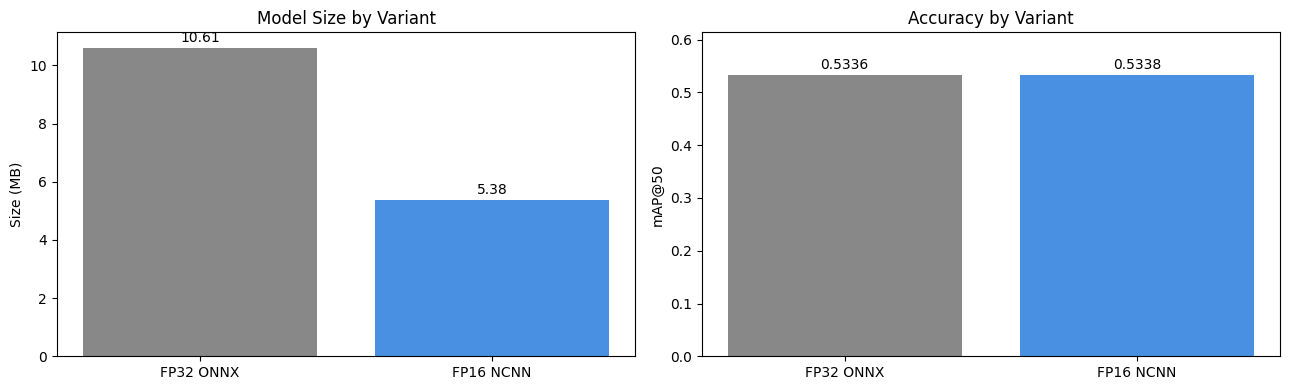

In [31]:
# ============================================================
# 3.6 - Plot compression trade-off (size vs mAP)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(report['variant'], report['size_MB'], color=['#888', '#4a90e2', '#2ecc71'])
ax[0].set_ylabel('Size (MB)'); ax[0].set_title('Model Size by Variant')
for i, v in enumerate(report['size_MB']):
    ax[0].text(i, v + max(report['size_MB']) * 0.02, f'{v}', ha='center')

ax[1].bar(report['variant'], report['mAP50'], color=['#888', '#4a90e2', '#2ecc71'])
ax[1].set_ylabel('mAP@50'); ax[1].set_title('Accuracy by Variant')
ax[1].set_ylim(0, max(report['mAP50']) * 1.15)
for i, v in enumerate(report['mAP50']):
    ax[1].text(i, v + max(report['mAP50']) * 0.02, f'{v}', ha='center')
plt.tight_layout(); plt.show()

In [32]:

# 4.1 - Stage the model files

DEPLOY = PROJECT_ROOT / 'deploy_pi'
(DEPLOY / 'models').mkdir(parents=True, exist_ok=True)

ncnn_fp16_dst = DEPLOY / 'models' / Path(ncnn_fp16_dir).name
if ncnn_fp16_dst.exists(): shutil.rmtree(ncnn_fp16_dst)
shutil.copytree(ncnn_fp16_dir, ncnn_fp16_dst)


shutil.copy(PROJECT_ROOT / 'compression_report.csv', DEPLOY / 'compression_report.csv')

print("Models staged at:", DEPLOY / 'models')
for p in (DEPLOY / 'models').iterdir():
    print(" -", p.name)

Models staged at: /content/edge_traffic/deploy_pi/models
 - best_ncnn_model
